In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.CRNGenerator import CRNGenerator, CRNCompletor
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import map_index_to_parameter
from Input_Output_Rxn_Networks.ReactionSequenceGenerator import map_indices_to_reactions
from copy import deepcopy
import gymnasium as gym
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time
import pathos.multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool
import warnings
warnings.filterwarnings("ignore")

import multiprocess.context as ctx
ctx._force_start_method('fork')

n_threads = mp.cpu_count()

In [3]:
# Select Device
device = torch.device("cuda" if 
torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# Hyperparameters
N_CPUs = os.cpu_count()                 # Number of CPUs to use for parallel processing 
N_grid = 200                            # Number of grid points for the parameter range
N_samples = 8*N_CPUs                  # Number of samples to generate for Monte Carlo estimations
entropy_weight = 0.25                   # Initial Entropy weight for the loss function
entropy_update_coefficient = 0.9        # Coefficient for updating the entropy weight
entropy_schedule = 20                   # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.01           # Minimum entropy weight
num_epochs = 1000                       # Number of epochs to train the model
learning_rate = 1e-5                    # Learning rate for the optimizer   
t_final = 100                           # Final time for the simulation

risk = 0.95
risk_update = 0.00
max_risk = 1.00
risk_schedule = 20

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 0: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 1: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 2: X_1 -> 0 ; Rate Constant: 1.0
Reaction 3: X_2 -> 0 ; Rate Constant: 0.10000000149011612u
Reaction 4: 0 -> Z_1 ; Rate Constant: 10.0
Reaction 5: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0
Reaction 6: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Simulation Time: 0.08
14.896259716617443


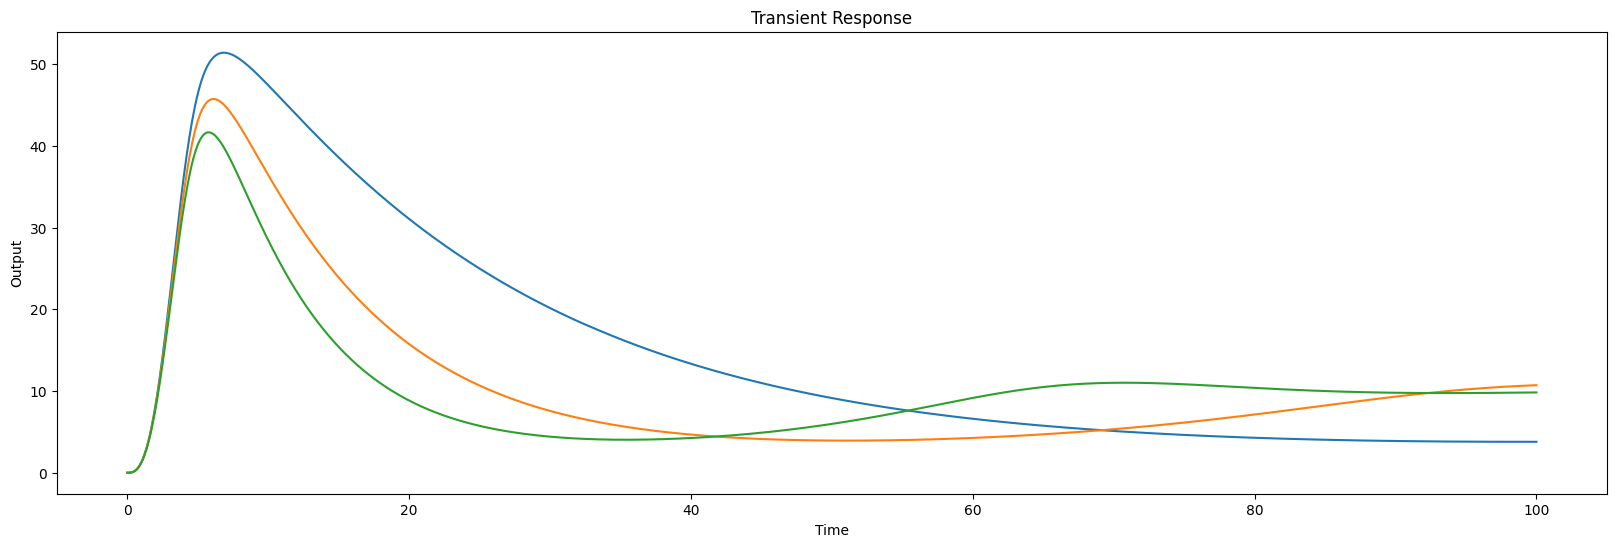

In [5]:
# Construct an IOCRN modeling a Gene Expression process controlled by the AIF controller
species_labels = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs_labels = ['u']
stoichiometry_reactants = np.array([[0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 1, 0], [1, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1]], dtype=np.int8)
stoichiometry_products = np.array([[1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = 10; theta = 1; eta = 0.1
parameters = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 1, 0, 0, 0]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_AIF = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs, species_labels, inputs_labels)
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN_AIF.print_reactions()

# Transient Response for the AIF Controller
u = np.array([[0.5], [1], [1.5]], dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

tic = time.time()
outputs_AIF_transient = IOCRN_AIF.transient_response(u, initial_condition, time_horizon)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
for i in range(len(outputs_AIF_transient)):
    plt.plot(time_horizon, outputs_AIF_transient[i])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')

print(np.linalg.norm(10 - outputs_AIF_transient[0]) / np.sqrt(len(outputs_AIF_transient[0])))

In [6]:
# Construct the parameter grid
param_1 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_2 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_3 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
parameter_grid = np.stack([param_1, param_2, param_3], axis=0)

In [7]:
# Construct the CRN Generator and Completor
num_species = 4
num_reactions = 2
num_inputs = 1

width = 2**12

# Define RSG_Attributes
class RSG_Attributes:
	LSTM_hidden_size = width
	FFNN_hidden_size = [width, width, width]
	FFNN_num_layers = [3, 3, 3]
	weight = [None, None, None]

# Define PSG_Attributes
class PSG_Attributes:
	LSTM_hidden_size = width
	FFNN_hidden_size = width
	FFNN_num_layers = 3
	weight = None

MyCRN_Generator = CRNGenerator(num_species, num_reactions, 1, num_inputs, parameter_grid, N_samples, RSG_Attributes, PSG_Attributes).to(device)
MyCRN_Completor = CRNCompletor(num_species, num_reactions, 1, num_inputs, parameter_grid, N_samples, RSG_Attributes, PSG_Attributes).to(device)

In [8]:
# Design the loss function
def Performance_Metric(r, y):
    # return np.linalg.norm(r - y) / np.sqrt(len(y)) # + np.abs(y[-1] - r) 
    y = np.transpose(y, (1, 0, 2))
    weight = np.ones(y.shape[0])
    weight[(len(weight)//5)*4:] = weight[(len(weight)//5)*4:]*2
    weight[:(len(weight)//5)] = weight[:(len(weight)//5)]*0.25

    # reshape weight to match the shape of y
    weight = np.repeat(weight, y.shape[1]*y.shape[2]).reshape(y.shape[0], y.shape[1], y.shape[2])

    return (weight*np.abs(r - y)).mean()

def SS_Metric(r, y_ss):
    return np.abs(r - y_ss)

def unzip(params):
    out = []
    for i in range(len(params[0])):
        out.append([ p[i] for p in params ])
    return out

def _compute_single_loss(crn, inputs, initial_condition, time_horizon, r, threshold=1000):
    y, x = crn.transient_response(inputs, initial_condition, time_horizon, return_states=True)
    y = np.minimum(y, threshold)
    y = np.maximum(y,0)
    y[np.isnan(y)] = threshold
    y[np.isinf(y)] = threshold
    return Performance_Metric(r, y)

# def compute_loss(self, r, initial_condition, time_horizon, h0, c0, manifold_dim, CRN_Fixed):
#     network_outputs = self.forward(h0, c0, manifold_dim)
#     stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter, total_logP, total_entropy, h, c = network_outputs
#     input_influence_matrix = input_influence_matrix*0. #TODO check
#     network_outputs=stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter.T
#     network_outputs = unzip(network_outputs)

#     # Get maximum number of process workers\
#     # n_threads = mp.cpu_count()
#     with Pool(n_threads) as pool:
#         loss_for_each_sample = pool.map(
#             _compute_single_loss,
#             [(no, r, initial_condition, time_horizon, CRN_Fixed) for no in network_outputs]
#         )

#     loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
#     loss_mean = torch.mean(loss_for_each_sample)

#     return loss_for_each_sample, loss_mean, total_logP, total_entropy

# MyCRN_Generator.Performance_Metric = types.MethodType(Performance_Metric, MyCRN_Generator)
# MyCRN_Generator.compute_loss = types.MethodType(compute_loss, MyCRN_Generator)


In [9]:
# Create a batched Environment
class CRNEnv(gym.Env):
    """
    Custom Environment that follows gym interface
    This is the basic environment for CRNs.
    """
    def __init__(self, CRN_template, max_num_reactions):
        super(CRNEnv, self).__init__()
        self.CRN_template = CRN_template
        self.action_space = gym.spaces.Dict({
            'reactants space': gym.spaces.Discrete(self.CRN_template.get_complexes_range()),
            'products space': gym.spaces.Discrete(self.CRN_template.get_complexes_range()),
            'input influence space': gym.spaces.Discrete(self.CRN_template.num_inputs + 1),
            'rate constant space': gym.spaces.Box(low=0.0, high=np.inf, shape=(1,), dtype=np.float32)
        })
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.CRN_template.num_species,), dtype=np.float32)
        self.state = deepcopy(self.CRN_template)
        self.num_added_reactions = 0
        self.max_num_reactions = max_num_reactions

    def reset(self):
        self.state = deepcopy(self.CRN_template)
        return self.state

    def step(self, action):
        if self.state.num_unknown_parameters > 0:
            self.state.set_next_unknown_parameter(action)
        else:
            self.state.add_reaction(action)
            self.num_added_reactions += 1
        
        if self.num_added_reactions < self.max_num_reactions:
            reward = 0
            done = False 
        else:
            reward = self.get_reward()
            done = True  
        
        info = {} 

        return self.state, reward, done, info

    def render(self, mode='human'):
        if mode == 'human':
            self.state.print_reactions()
        else:
            pass  

    def get_reward(self):
        u = np.array([[0.5], [1], [1.5]], dtype=np.float32)
        initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
        time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)
        # TODO hardcoded reference by now
        return _compute_single_loss(self.state, u, initial_condition, time_horizon, r, threshold=1000)
        

# Helper functions (outside the class)
def reset_env(env):
    output = env.reset()
    return env, output

def step_env(args):
    env, action = args
    output = env.step(action)
    return env, output

class VecEnv():
    def __init__(self, envs, N_CPUs=os.cpu_count()):
        self.envs = envs
        self.N_CPUs = N_CPUs
        self.pool = mp.Pool(processes=N_CPUs)

    def reset(self):
        output = self.pool.map(reset_env, self.envs)
        self.envs = [env for env, _ in output]
        outputs = [output for _, output in output]
        return outputs

    def step(self, actions):
        output = self.pool.map(step_env, zip(self.envs, actions))
        self.envs = [env for env, _ in output]
        outputs = [output for _, output in output]
        return outputs

    def close(self):
        self.pool.close()
        self.pool.join()

class SerialVecEnv():
    def __init__(self, envs):
        self.envs = envs

    def reset(self):
        return [env.reset() for env in self.envs]

    def step(self, actions):
        return [env.step(action) for env,action in zip(self.envs, actions)]

In [10]:
# Construct Agent
class RecurrentAgent:
    def __init__(self, env, completor, learning_rate=1e-3):
        self.env = env
        self.completor = completor
        self.queue = []
        self.last_logP = None
        self.last_entropy = None
        self.optimizer = torch.optim.Adam(self.completor.parameters(), lr=learning_rate)

    def act(self):
        if len(self.queue) == 0 or len(self.queue[0]) == 0:
            batched_action_set, total_logP, total_entropy = self.completor()
            self.queue = batched_action_set
            self.last_logP = total_logP
            self.last_entropy = total_entropy

        action = [lst.pop(0) for lst in self.queue]
        return action
    
    def update(self, rewards):
        self.optimizer.zero_grad()
        loss_for_each_sample = torch.tensor(rewards, requires_grad=False).to(self.completor.device)
        loss_for_each_sample_comp = loss_for_each_sample # if you need to do some postprocessing of it
        entropy_mean = torch.mean(self.last_entropy)
        total_entropy = torch.mean(self.last_entropy, dim=0)

        loss_for_gradient =  (loss_for_each_sample_comp.detach() * self.last_logP) - entropy_weight * entropy_mean - (entropy_weight * total_entropy.detach() * self.last_logP)
        top_k = torch.topk(loss_for_each_sample, int(MyCRN_Generator.num_samples * (1.-risk)), largest=False).indices # - entropy_weight*total_entropy

        best = loss_for_each_sample[top_k[0]]
        worst = loss_for_each_sample[top_k[-1]]
        avg = loss_for_each_sample[top_k].mean()

        loss_for_gradient = torch.mean(loss_for_gradient[top_k]).backward()

        #clip gradients
        # torch.nn.utils.clip_grad_norm_(MyCRN_Generator.parameters(), 0.01)
        self.optimizer.step()
        print('best', best.item(), 'worst', worst.item(), 'avg', avg.item())



In [12]:
from tqdm import tqdm
IOCRN_AIF.set_parameters(5, np.nan)
# vec_env = VecEnv([CRNEnv(IOCRN_AIF, num_reactions) for _ in range(N_samples)], N_CPUs=N_CPUs)
vec_env = SerialVecEnv([CRNEnv(IOCRN_AIF, num_reactions) for _ in range(N_samples)])
recurrent_agent = RecurrentAgent(vec_env, MyCRN_Completor)
r = np.array([[10], [10], [10]], dtype=np.float32)

# Training Loop
for epoch in tqdm(range(num_epochs)):
    obs = vec_env.reset()
    rewards = []
    for i in range(3):
        # Take an action
        action = recurrent_agent.act()
        
        # Step the environment
        output = vec_env.step(action)

        rewards = [o[1] for o in output] # we are just keeping the last one here

    # Update the agent
    recurrent_agent.update(rewards)

    
# Render the environment
vec_env.envs[0].render()

  0%|          | 1/1000 [01:14<20:48:14, 74.97s/it]

best 1.217153944318127 worst 5.9210516340458295 avg 4.175037565782502


Traceback (most recent call last):
  File "/Users/mfilo/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/base.py", line 154, in fun
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
    return self.fun_single(t, y)
  File "/Users/mfilo/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/base.py", line 23, in fun_wrapped
    return np.asarray(fun(t, y), dtype=dtype)
  File "/Users/mfilo/Library/CloudStorage/GoogleDrive-maurice.g.filo@gmail.com/My Drive/My Github/CRN-GenerativeAI/CRNGenAI/Input_Output_Rxn_Networks/IOCRN_MassAction.py", line 108, in <lambda>
    lambda t, y: self.rate_function(t, y, input),  # ODE function
  File "/Users/mfilo/Library/CloudStorage/GoogleDrive-maurice.g.filo@gmail.com/My Drive/My Github/CRN-GenerativeAI/CRNGenAI/Input_Output_Rxn_Networks/IOCRN_MassAction.py", line 93, in rate_function
 

: 

In [ ]:
# Train the CRN generator
r = np.array([[10], [10], [10]], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
manifold_dim = 0
h0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
c0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
optimizer = torch.optim.Adam(MyCRN_Generator.parameters(), lr=learning_rate)
tic = time.time()

# Clear the output file
of = open("output.txt", "w")
of.close()

losses = {
    "mean": [],
    "best": [],
    "worst": [],
    "entropy": [],
    "entropy_weight": [],
    "distance": []
}


for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss_for_each_sample, loss_mean, total_logPs, total_entropy = MyCRN_Generator.compute_loss(r, initial_condition, time_horizon, h0, c0, manifold_dim, IOCRN_AIF)
    entropy_mean = torch.mean(total_entropy)

    # Non risky policy gradients
    # loss_for_gradient = torch.mean(loss_for_each_sample.detach() * total_logPs) - entropy_weight * entropy_mean - torch.mean(entropy_weight * total_entropy.detach() * total_logPs)

    # print("MEAN", loss_for_each_sample.mean())

    # Risky policy gradients
    
    loss_for_each_sample_comp = loss_for_each_sample / loss_for_each_sample.min()

    loss_for_gradient =  (loss_for_each_sample_comp.detach() * total_logPs) - entropy_weight * entropy_mean - (entropy_weight * total_entropy.detach() * total_logPs)
    top_k = torch.topk(loss_for_each_sample, int(MyCRN_Generator.num_samples * (1.-risk)), largest=False).indices # - entropy_weight*total_entropy
    
    best = loss_for_each_sample[top_k[0]]
    worst = loss_for_each_sample[top_k[-1]]

    loss_for_gradient = torch.mean(loss_for_gradient[top_k])  # /loss_for_gradient[top_k[0]]
    # print(loss_for_gradient.max())

    loss_mean = loss_for_each_sample[top_k].mean()

    
    loss_for_gradient.backward()

    #clip gradients
    # torch.nn.utils.clip_grad_norm_(MyCRN_Generator.parameters(), 0.01)
    optimizer.step()

    if True:
        of = open("output.txt", "a")
        print('Epoch: %d, Mean Loss: %.4f (real %.4f, best %.4f, worst %.4f), Entropy: %.4f, Entropy Weight: %.4f, Risk %.4f' % (epoch, loss_mean.item(), loss_mean.item(), best.item(),  worst.item(), entropy_mean.item(), entropy_weight, risk), file=of)
        of.close()
        losses["distance"].append(loss_mean.item())
        losses["mean"].append(loss_for_gradient.item())
        losses["best"].append(best.item())
        losses["worst"].append(worst.item())
        losses["entropy"].append(entropy_mean.item())
        losses["entropy_weight"].append(entropy_weight)

    if epoch % entropy_schedule == 0 and epoch != 0:
        entropy_weight = max(entropy_weight * entropy_update_coefficient, minimum_entropy_weight)

    if epoch % risk_schedule == 0 and epoch != 0:
        risk = min(risk + risk_update, max_risk)

toc = time.time()
print('Training Time: %.2f' % (toc - tic))

In [ ]:
# print all the information about the losses:

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.plot(losses["mean"], label="Mean Loss")
plt.plot(losses["best"], label="Best Loss")
plt.plot(losses["worst"], label="Worst within p")
# plt.yscale("log")
plt.xlabel("Episode")
plt.ylabel("Loss")

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses["distance"], label="Distance Loss")
plt.plot(losses["entropy"], label="Entropy")
plt.plot(losses["entropy_weight"], label="Entropy Weight")
# plt.yscale("log")
plt.xlabel("Episode")

plt.legend()


In [ ]:
# Test the trained model
n_repeat=2

Performance = []
IOCRN_APIDF2 = []
stoichiometry_reactants = []
stoichiometry_products = []
input_influence_matrix = []
parameter = []

for _ in range(n_repeat):
    h0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
    c0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
    stoichiometry_reactants_, stoichiometry_products_, input_influence_matrix_, parameter_, _, _, _, _= MyCRN_Generator(h0, c0, manifold_dim)
    input_influence_matrix_ = input_influence_matrix_*0. #TODO check

    # Transient Response for the AIF Controller
    u = np.array([[0.5], [1], [1.5]], dtype=np.float32)
    initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
    time_horizon = np.linspace(0, t_final, 100, dtype=np.float32)

    colors = ['r', 'g', 'b']


    for i in range(MyCRN_Generator.num_samples):
        S_R = np.concatenate((IOCRN_AIF.stoichiometry_reactants, stoichiometry_reactants_[i,:,:]), axis=1)
        S_P = np.concatenate((IOCRN_AIF.stoichiometry_products, stoichiometry_products_[i,:,:]),  axis=1)
        S_I = np.concatenate((IOCRN_AIF.input_influence_matrix, input_influence_matrix_[i,:,:]), axis=1)
        p = np.concatenate((IOCRN_AIF.parameters, parameter_[:-1, i]),axis=0)
        p[5] = parameter_[-1, i]
        IOCRN_APIDF2.append(IOCRN_MassAction(S_R, S_P, p, S_I, np.array([2], dtype=np.int8)))
        outputs_transient = IOCRN_APIDF2[-1].transient_response(u, initial_condition, time_horizon)

        

        score = Performance_Metric(r, np.array(outputs_transient))
        Performance.append(score)

        stoichiometry_products.append(stoichiometry_products_[i,:,:])
        stoichiometry_reactants.append(stoichiometry_reactants_[i,:,:])
        input_influence_matrix.append(input_influence_matrix_[i,:,:])
        parameter.append(parameter_[:,i])

        if score<2000.:
            for j in range(len(outputs_transient)):
                plt.plot(time_horizon, outputs_transient[j], alpha=0.05, color=colors[j])


    print('Performance: %.4f' % np.mean(Performance), 'best: %.4f' % np.min(Performance), 'worst: %.4f' % np.max(Performance))


stoichiometry_reactants = np.array(stoichiometry_reactants)
stoichiometry_products = np.array(stoichiometry_products)
input_influence_matrix = np.array(input_influence_matrix)
parameter = np.array(parameter)

# Sort the performance in ascending order
indices = np.argsort(Performance)

In [ ]:
# top 10
plt.hist(Performance, bins=50)

In [ ]:
indices[i]

In [ ]:
parameter.shape

In [ ]:
i = indices[5]
IOCRN_APIDF2[i].print_reactions(species, inputs)

u = np.array([[0.5*i+0.5] for i in range(6)], dtype=np.float32)

time_horizon = np.linspace(0, t_final+100, 1000, dtype=np.float32)

# outputs_transient = IOCRN_APIDF2[i].transient_response(u, initial_condition, time_horizon)
S_R = np.concatenate((IOCRN_AIF.stoichiometry_reactants, stoichiometry_reactants[i,:,:]), axis=1)
S_P = np.concatenate((IOCRN_AIF.stoichiometry_products, stoichiometry_products[i,:,:]),  axis=1)
S_I = np.concatenate((IOCRN_AIF.input_influence_matrix, input_influence_matrix[i,:,:]), axis=1)
p = np.concatenate((IOCRN_AIF.parameters, parameter[i, :-1]),axis=0)
p[5] = parameter[i, -1]
test = IOCRN_MassAction(S_R, S_P, p, S_I, np.array([2], dtype=np.int8))

outputs_transient = test.transient_response(u, initial_condition, time_horizon)


for j in range(len(outputs_transient)):
    plt.plot(time_horizon, outputs_transient[j], alpha=0.5)#, color=colors[j])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response. Score %.2f' % Performance[i])
# plt.legend()

In [ ]:
print(p)

In [ ]:
# torch.save(MyCRN_Generator.state_dict(), 'SavedModels/WeirdCRN_e5000.pt')

In [ ]:
# OtherCRN = torch.load('SavedModels/WeirdCRN_e5000.pt')